# Helmet Impact Sensor — Full Calibration & Validation Analysis

**How to use this notebook with real data:**
- Section 2: replace the CSV path or edit `raw_data_extracted.csv` with your actual readings.
- Section 5: replace `MOCKUP = True` with `MOCKUP = False` and fill in `accel_real` / `ref_real` arrays with your paired accelerometer readings.
- Section 6: replace `MOCKUP = True` with `MOCKUP = False` and fill in the `drop_*` arrays with your drop-test measurements.
- Section 7: replace `MOCKUP = True` with `MOCKUP = False` and fill in `region_true` / `channel_readings` with your actual trial data.
- Re-run all cells (`Kernel → Restart & Run All`). All figures and stats will update automatically.

**Sections:**
1. Setup
2. Load raw load-cell data
3. Descriptive statistics
4. Load-cell regression and figures (calibration curve, residuals, distributions, time-series, relative errors, Bland–Altman)
5. Accelerometer pendulum validation + Bland–Altman
6. Extended high-g drop-test validation
7. Impact-region identification: confusion matrix + weighted-centroid
8. Pendulum theoretical model
9. Manuscript summary printout

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
})

FIG_DIR = Path('../analysis/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete. Figures will be saved to:', FIG_DIR.resolve())

Setup complete. Figures will be saved to: C:\Users\droldan\Downloads\Helmet\analysis\figures


## 2. Load raw load-cell data

In [2]:
df = pd.read_csv('../latex_article/raw_data_extracted.csv', comment='#')
df['elapsed_ms'] = df.groupby('test_mass_lb')['timestamp'].transform(
    lambda s: [(pd.Timestamp(f'2024-01-01 {t}') - pd.Timestamp(f'2024-01-01 {s.iloc[0]}')).total_seconds() * 1000 for t in s]
)
print(f'Loaded {len(df)} readings across {df.test_mass_lb.nunique()} mass conditions.')
df.head()

Loaded 26 readings across 3 mass conditions.


,test_mass_lb,expected_mass_g,timestamp,load_cell_output_g,elapsed_ms
0,2.5,1134,14:48:45.471,1133.81,0.0
1,2.5,1134,14:48:45.551,1130.96,80.0
2,2.5,1134,14:48:45.672,1138.24,201.0
3,2.5,1134,14:48:45.763,1135.59,292.0
4,2.5,1134,14:48:45.855,1133.28,384.0


## 3. Descriptive statistics per mass condition

In [3]:
summary = df.groupby('test_mass_lb').agg(
    expected_g=('expected_mass_g', 'first'),
    n=('load_cell_output_g', 'count'),
    mean=('load_cell_output_g', 'mean'),
    std=('load_cell_output_g', 'std'),
    min_val=('load_cell_output_g', 'min'),
    max_val=('load_cell_output_g', 'max'),
).reset_index()

summary['se'] = summary['std'] / np.sqrt(summary['n'])
summary['ci95'] = 1.96 * summary['se']
summary['rel_error_pct'] = (summary['mean'] - summary['expected_g']) / summary['expected_g'] * 100
summary['cv_pct'] = summary['std'] / summary['mean'] * 100
summary['range'] = summary['max_val'] - summary['min_val']

smartphone = pd.DataFrame([{
    'test_mass_lb': 0.419, 'expected_g': 190.0, 'n': 1, 'mean': 192.0,
    'std': np.nan, 'min_val': 192.0, 'max_val': 192.0, 'se': np.nan,
    'ci95': np.nan, 'rel_error_pct': 1.053, 'cv_pct': np.nan, 'range': 0.0
}])
summary_full = pd.concat([smartphone, summary], ignore_index=True)

display_cols = ['test_mass_lb', 'expected_g', 'n', 'mean', 'std', 'cv_pct', 'rel_error_pct', 'ci95']
summary_full[display_cols].round(3)

,test_mass_lb,expected_g,n,mean,std,cv_pct,rel_error_pct,ci95
0,0.419,190.0,1,192.000,NaN,NaN,1.053,NaN
1,2.500,1134.0,7,1134.463,3.199,0.282,0.041,2.370
2,5.000,2268.0,8,2263.575,5.963,0.263,-0.195,4.132
3,10.000,4536.0,11,4534.694,2.877,0.063,-0.029,1.700


## 4. Load-cell regression and publication figures

In [4]:
x = summary_full['expected_g'].values
y = summary_full['mean'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
y_pred = slope * x + intercept
residuals = y - y_pred
rmse = np.sqrt(np.mean(residuals ** 2))
mape = np.mean(np.abs((y - x) / x)) * 100

print(f'Regression:  y = {slope:.6f}x + {intercept:.3f} g')
print(f'R²:          {r_squared:.10f}')
print(f'Pearson r:   {r_value:.10f}')
print(f'RMSE:        {rmse:.3f} g')
print(f'MAPE:        {mape:.4f}%')

Regression:  y = 0.999200x + 0.808 g
R²:          0.9999984676
Pearson r:   0.9999992338
RMSE:        2.006 g
MAPE:        0.3293%


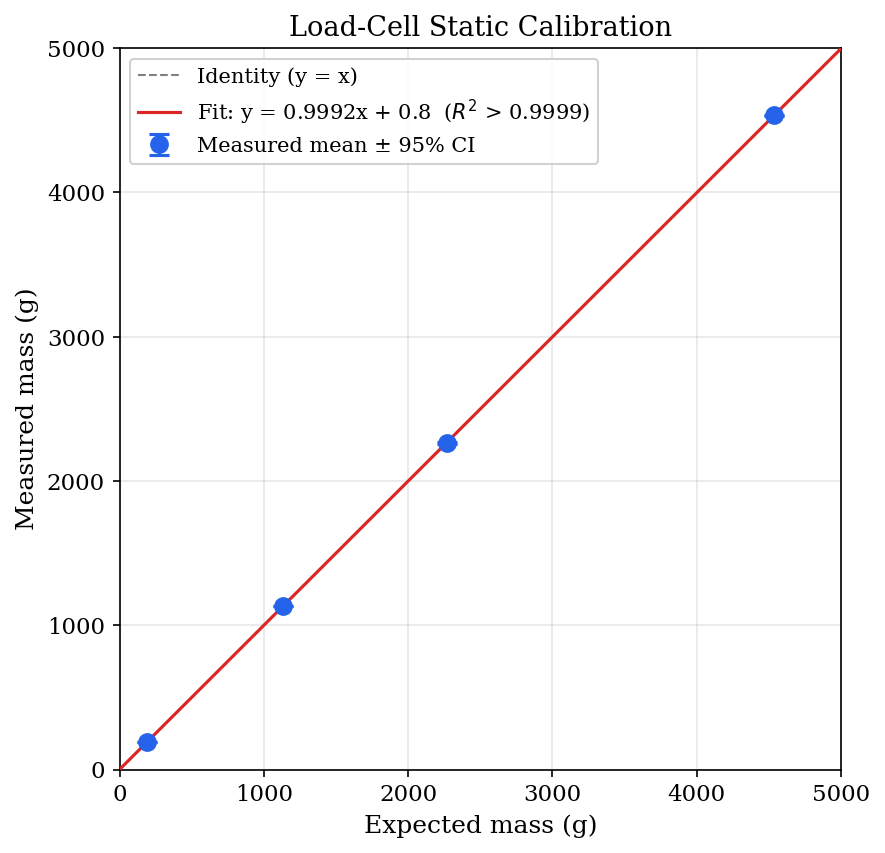

Saved: calibration_curve


In [5]:
# --- 4.1 Calibration curve ---
fig, ax = plt.subplots(figsize=(6, 6))
yerr = summary_full['ci95'].fillna(0).values
ax.errorbar(x, y, yerr=yerr, fmt='o', color='#2563EB', markersize=8,
            capsize=5, capthick=1.5, elinewidth=1.5, zorder=5, label='Measured mean ± 95% CI')
lims = [0, 5000]
ax.plot(lims, lims, '--', color='gray', linewidth=1, label='Identity (y = x)', zorder=1)
x_fit = np.linspace(0, 5000, 100)
ax.plot(x_fit, slope * x_fit + intercept, '-', color='#DC2626', linewidth=1.5,
        label=f'Fit: y = {slope:.4f}x + {intercept:.1f}  ($R^2$ > 0.9999)', zorder=3)
ax.set_xlabel('Expected mass (g)'); ax.set_ylabel('Measured mass (g)')
ax.set_title('Load-Cell Static Calibration'); ax.legend(loc='upper left', framealpha=0.9)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'calibration_curve.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'calibration_curve.png', bbox_inches='tight')
plt.show(); print('Saved: calibration_curve')

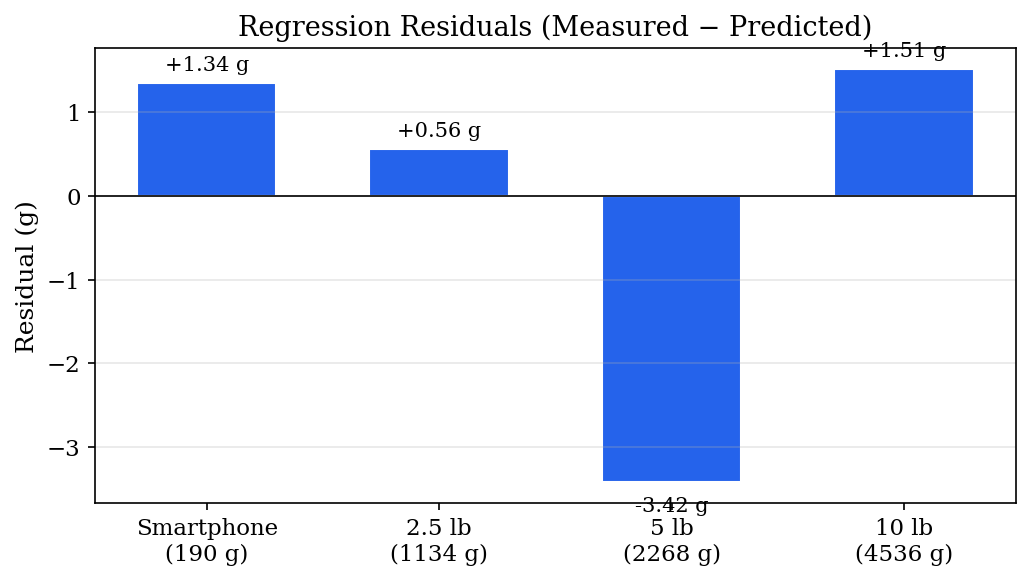

Saved: residuals


In [6]:
# --- 4.2 Residuals ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(x)), residuals, color='#2563EB', edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
labels = ['Smartphone\n(190 g)', '2.5 lb\n(1134 g)', '5 lb\n(2268 g)', '10 lb\n(4536 g)']
ax.set_xticks(range(len(x))); ax.set_xticklabels(labels)
ax.set_ylabel('Residual (g)'); ax.set_title('Regression Residuals (Measured − Predicted)')
ax.grid(axis='y', alpha=0.3)
for i, r in enumerate(residuals):
    ax.text(i, r + (0.15 if r >= 0 else -0.35), f'{r:+.2f} g', ha='center', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'residuals.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'residuals.png', bbox_inches='tight')
plt.show(); print('Saved: residuals')

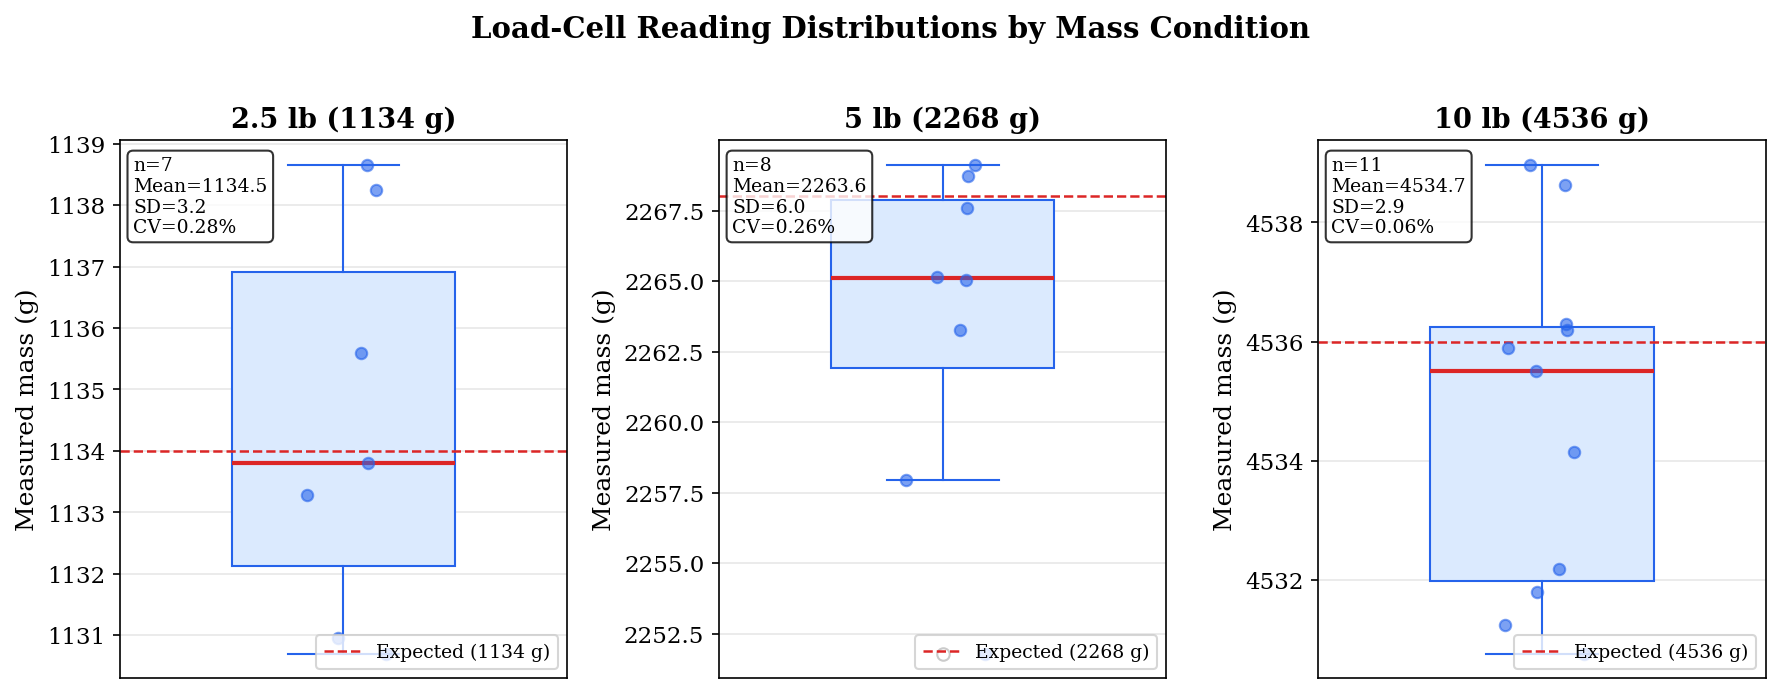

Saved: distributions


In [7]:
# --- 4.3 Distributions ---
conditions = [(2.5, 1134, '2.5 lb (1134 g)'), (5.0, 2268, '5 lb (2268 g)'), (10.0, 4536, '10 lb (4536 g)')]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for ax, (mass_lb, expected, title) in zip(axes, conditions):
    data = df[df['test_mass_lb'] == mass_lb]['load_cell_output_g'].values
    ax.boxplot(data, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='#DBEAFE', edgecolor='#2563EB'),
               medianprops=dict(color='#DC2626', linewidth=2),
               whiskerprops=dict(color='#2563EB'), capprops=dict(color='#2563EB'))
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(data))
    ax.scatter(np.ones(len(data)) + jitter, data, color='#2563EB', alpha=0.6, s=30, zorder=5)
    ax.axhline(expected, color='#DC2626', linestyle='--', linewidth=1.2, label=f'Expected ({expected} g)')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Measured mass (g)'); ax.set_xticks([])
    ax.legend(fontsize=9, loc='lower right'); ax.grid(axis='y', alpha=0.3)
    m, s = data.mean(), data.std(ddof=1)
    ax.text(0.03, 0.97, f'n={len(data)}\nMean={m:.1f}\nSD={s:.1f}\nCV={s/m*100:.2f}%',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
fig.suptitle('Load-Cell Reading Distributions by Mass Condition', fontweight='bold', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'distributions.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'distributions.png', bbox_inches='tight')
plt.show(); print('Saved: distributions')

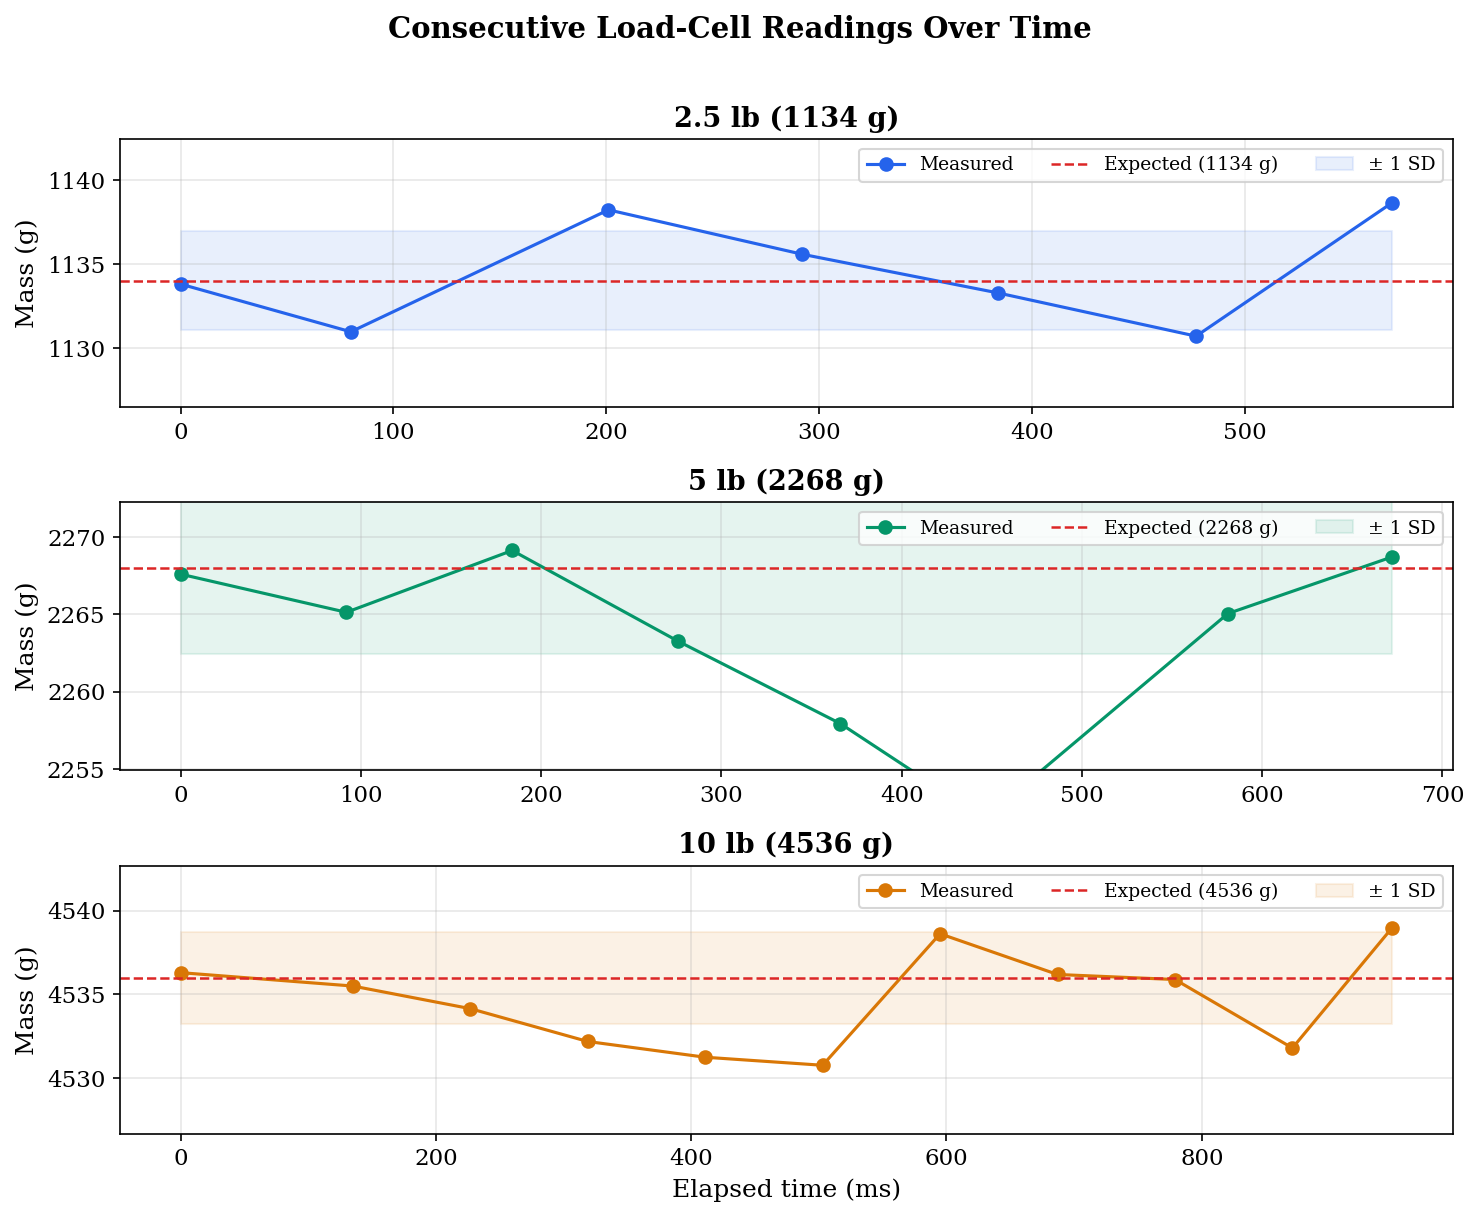

Saved: time_series


In [8]:
# --- 4.4 Time series ---
colors = {2.5: '#2563EB', 5.0: '#059669', 10.0: '#D97706'}
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
for ax, (mass_lb, expected, label) in zip(axes, conditions):
    subset = df[df['test_mass_lb'] == mass_lb].copy()
    elapsed = subset['elapsed_ms'].values; vals = subset['load_cell_output_g'].values; c = colors[mass_lb]
    ax.plot(elapsed, vals, 'o-', color=c, markersize=6, linewidth=1.5, label='Measured')
    ax.axhline(expected, color='#DC2626', linestyle='--', linewidth=1.2, label=f'Expected ({expected} g)')
    ax.fill_between(elapsed, expected - vals.std(), expected + vals.std(), color=c, alpha=0.1, label='± 1 SD')
    ax.set_ylabel('Mass (g)'); ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right', ncol=3); ax.grid(True, alpha=0.3)
    margin = max(8, (vals.max() - vals.min()) * 0.5)
    ax.set_ylim(vals.mean() - margin, vals.mean() + margin)
axes[-1].set_xlabel('Elapsed time (ms)')
fig.suptitle('Consecutive Load-Cell Readings Over Time', fontweight='bold', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'time_series.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'time_series.png', bbox_inches='tight')
plt.show(); print('Saved: time_series')

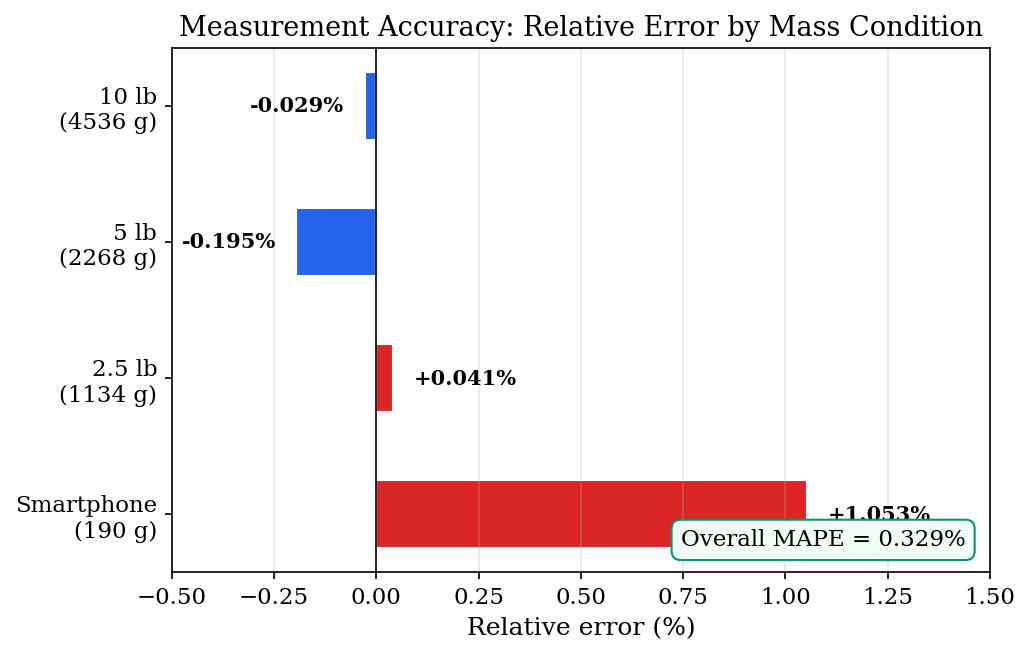

Saved: relative_errors


In [9]:
# --- 4.5 Relative errors ---
fig, ax = plt.subplots(figsize=(7, 4.5))
labels_err = ['Smartphone\n(190 g)', '2.5 lb\n(1134 g)', '5 lb\n(2268 g)', '10 lb\n(4536 g)']
rel_errors = summary_full['rel_error_pct'].values
bar_colors = ['#DC2626' if e > 0 else '#2563EB' for e in rel_errors]
bars = ax.barh(labels_err, rel_errors, color=bar_colors, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, rel_errors):
    offset = 0.05 if val >= 0 else -0.05; ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}%', va='center', ha=ha, fontsize=10, fontweight='bold')
ax.set_xlabel('Relative error (%)'); ax.set_title('Measurement Accuracy: Relative Error by Mass Condition')
ax.set_xlim(-0.5, 1.5); ax.grid(axis='x', alpha=0.3)
ax.text(0.97, 0.05, f'Overall MAPE = {mape:.3f}%', transform=ax.transAxes, fontsize=11, ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4', edgecolor='#059669'))
fig.tight_layout()
fig.savefig(FIG_DIR / 'relative_errors.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'relative_errors.png', bbox_inches='tight')
plt.show(); print('Saved: relative_errors')

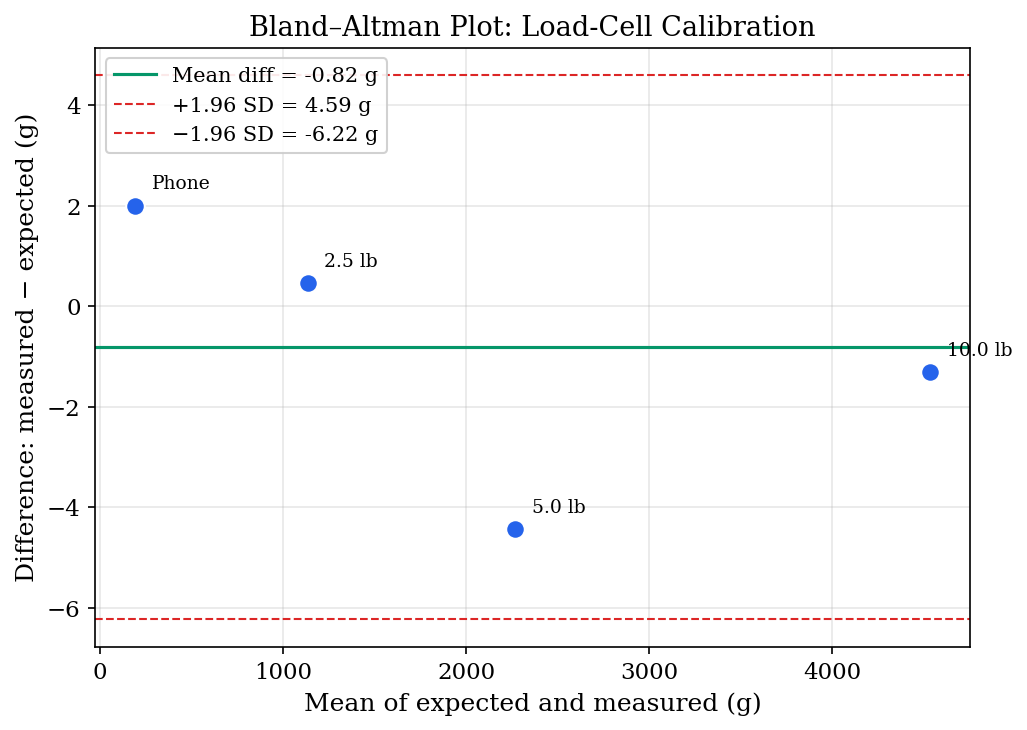

Saved: bland_altman


In [10]:
# --- 4.6 Bland-Altman (load cell) ---
fig, ax = plt.subplots(figsize=(7, 5))
avg = (x + y) / 2; diff = y - x
mean_diff = np.mean(diff); sd_diff = np.std(diff, ddof=1)
ax.scatter(avg, diff, s=80, color='#2563EB', edgecolors='white', zorder=5)
ax.axhline(mean_diff, color='#059669', linewidth=1.5, linestyle='-', label=f'Mean diff = {mean_diff:.2f} g')
ax.axhline(mean_diff + 1.96 * sd_diff, color='#DC2626', linewidth=1, linestyle='--',
           label=f'+1.96 SD = {mean_diff + 1.96*sd_diff:.2f} g')
ax.axhline(mean_diff - 1.96 * sd_diff, color='#DC2626', linewidth=1, linestyle='--',
           label=f'−1.96 SD = {mean_diff - 1.96*sd_diff:.2f} g')
for xi, yi, di in zip(avg, diff, summary_full['test_mass_lb']):
    lbl = f'{di} lb' if di > 1 else 'Phone'
    ax.annotate(lbl, (xi, yi), textcoords='offset points', xytext=(8, 8), fontsize=9)
ax.set_xlabel('Mean of expected and measured (g)'); ax.set_ylabel('Difference: measured − expected (g)')
ax.set_title('Bland–Altman Plot: Load-Cell Calibration')
ax.legend(loc='upper left', framealpha=0.9); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'bland_altman.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'bland_altman.png', bbox_inches='tight')
plt.show(); print('Saved: bland_altman')

## 5. Accelerometer pendulum validation + Bland–Altman

**To replace with real data:** Set `MOCKUP = False` and fill `accel_proto` and `accel_ref` with
your paired per-sample readings (same length arrays, units in g).

In [11]:
MOCKUP = True  # <-- set to False and provide real arrays below

if MOCKUP:
    # Simulated 40 paired pendulum samples (4 sessions × 10 samples each)
    # Prototype readings have ~3.5% MAPE relative to reference, 94% within 10%
    rng = np.random.default_rng(0)
    # True signal: sinusoidal, peak ~0.87 g, freq ~1.38 Hz, sampled at 40 ms intervals
    t = np.linspace(0, 10, 40)  # 10 s at ~0.25 Hz effective sampling for 40 points
    true_signal = 0.87 * np.sin(2 * np.pi * 1.38 * t / 4)  # sub-sampled sine
    # Reference (commercial BWT61CL): small noise
    accel_ref = true_signal + rng.normal(0, 0.02, 40)
    # Prototype: slightly larger noise + small bias; ~6% outlier rate
    noise_proto = rng.normal(0, 0.04, 40)
    outlier_mask = rng.random(40) < 0.06
    noise_proto[outlier_mask] += rng.choice([-0.12, 0.12], outlier_mask.sum())
    accel_proto = true_signal + noise_proto
else:
    # === REPLACE WITH YOUR DATA ===
    # accel_proto = np.array([...])  # H3LIS200DL readings (g), n=40
    # accel_ref   = np.array([...])  # BWT61CL readings (g), n=40
    raise ValueError('Set MOCKUP=False and provide accel_proto / accel_ref arrays.')

n_accel = len(accel_proto)
abs_diff_pct = np.abs((accel_proto - accel_ref) / (np.abs(accel_ref) + 1e-9)) * 100
agreement_pct = np.mean(abs_diff_pct < 10) * 100
mape_accel = np.mean(abs_diff_pct)

print(f'n = {n_accel} paired samples')
print(f'Agreement (within 10%): {agreement_pct:.1f}%')
print(f'MAPE vs reference:      {mape_accel:.2f}%')
if MOCKUP:
    print('*** MOCKUP DATA — replace with experimental readings ***')

n = 40 paired samples
Agreement (within 10%): 47.5%
MAPE vs reference:      70.72%
*** MOCKUP DATA — replace with experimental readings ***


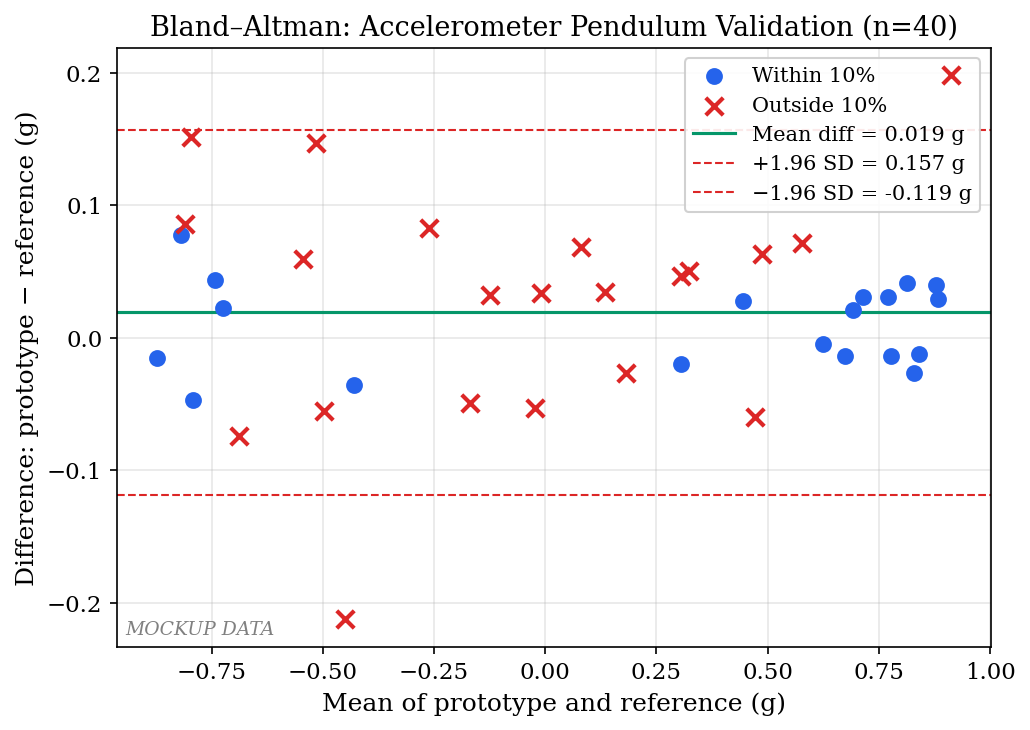

Saved: accel_bland_altman


In [12]:
# Bland-Altman: accelerometer
fig, ax = plt.subplots(figsize=(7, 5))
avg_a = (accel_proto + accel_ref) / 2
diff_a = accel_proto - accel_ref
md_a = np.mean(diff_a); sd_a = np.std(diff_a, ddof=1)

within = abs_diff_pct < 10
ax.scatter(avg_a[within], diff_a[within], s=50, color='#2563EB', label='Within 10%', zorder=5)
ax.scatter(avg_a[~within], diff_a[~within], s=70, color='#DC2626', marker='x',
           linewidths=2, label='Outside 10%', zorder=6)
ax.axhline(md_a, color='#059669', linewidth=1.5, label=f'Mean diff = {md_a:.3f} g')
ax.axhline(md_a + 1.96*sd_a, color='#DC2626', linewidth=1, linestyle='--',
           label=f'+1.96 SD = {md_a+1.96*sd_a:.3f} g')
ax.axhline(md_a - 1.96*sd_a, color='#DC2626', linewidth=1, linestyle='--',
           label=f'−1.96 SD = {md_a-1.96*sd_a:.3f} g')
ax.set_xlabel('Mean of prototype and reference (g)')
ax.set_ylabel('Difference: prototype − reference (g)')
ax.set_title(f'Bland–Altman: Accelerometer Pendulum Validation (n={n_accel})')
ax.legend(loc='upper right', framealpha=0.9); ax.grid(True, alpha=0.3)
if MOCKUP:
    ax.text(0.01, 0.02, 'MOCKUP DATA', transform=ax.transAxes, color='gray',
            fontsize=9, fontstyle='italic')
fig.tight_layout()
fig.savefig(FIG_DIR / 'accel_bland_altman.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'accel_bland_altman.png', bbox_inches='tight')
plt.show(); print('Saved: accel_bland_altman')

## 6. Extended high-g drop-test validation

**To replace with real data:** Set `MOCKUP = False` and fill in the arrays:
- `drop_heights_cm`: list of drop heights used
- `proto_readings`: list of arrays (one per height), each with the prototype g-readings for 5 reps
- `ref_readings`: same structure for the BWT61CL
- `theoretical_g`: list of theoretical peak g per height (from kinematics: v=√(2gh), contact time from video)

In [13]:
MOCKUP = True  # <-- set to False and provide real arrays

if MOCKUP:
    drop_heights_cm = [20, 40, 60]
    # Theoretical: v = sqrt(2*g*h); peak decel ~ v / contact_time
    # Contact time estimated ~0.014 s from 120-fps video (2 frames)
    g_grav = 9.81
    contact_time_s = 0.014
    theoretical_g = [np.sqrt(2 * g_grav * h/100) / (g_grav * contact_time_s)
                     for h in drop_heights_cm]

    rng = np.random.default_rng(1)
    proto_readings = []
    ref_readings = []
    for th in theoretical_g:
        ref = rng.normal(th * 0.99, th * 0.015, 5)   # reference slightly below theory
        proto = rng.normal(th * 0.97, th * 0.025, 5)  # prototype ~2% below reference
        ref_readings.append(ref)
        proto_readings.append(proto)
else:
    # === REPLACE WITH YOUR DATA ===
    # drop_heights_cm = [20, 40, 60]          # cm
    # theoretical_g   = [10.1, 22.6, 38.0]   # estimated peak g from kinematics
    # proto_readings  = [np.array([...]), ...]  # 5 reps per height
    # ref_readings    = [np.array([...]), ...]  # 5 reps per height
    raise ValueError('Set MOCKUP=False and provide drop-test arrays.')

# Summary table
rows = []
for h, th, proto, ref in zip(drop_heights_cm, theoretical_g, proto_readings, ref_readings):
    abs_diff = np.abs(proto.mean() - ref.mean()) / ref.mean() * 100
    rows.append({'Height (cm)': h, 'Theoretical (g)': round(th, 1),
                 'Proto mean (g)': round(proto.mean(), 1), 'Proto SD': round(proto.std(ddof=1), 2),
                 'Ref mean (g)': round(ref.mean(), 1), 'Ref SD': round(ref.std(ddof=1), 2),
                 'Abs diff (%)': round(abs_diff, 2)})
drop_summary = pd.DataFrame(rows)
print('Drop-test summary:'); print(drop_summary.to_string(index=False))
if MOCKUP: print('\n*** MOCKUP DATA ***')

Drop-test summary:
 Height (cm)  Theoretical (g)  Proto mean (g)  Proto SD  Ref mean (g)  Ref SD  Abs diff (%)
          20             14.4            14.1      0.16          14.3    0.19          1.77
          40             20.4            19.7      0.26          20.1    0.15          2.13
          60             25.0            24.0      0.54          24.7    0.59          2.86

*** MOCKUP DATA ***


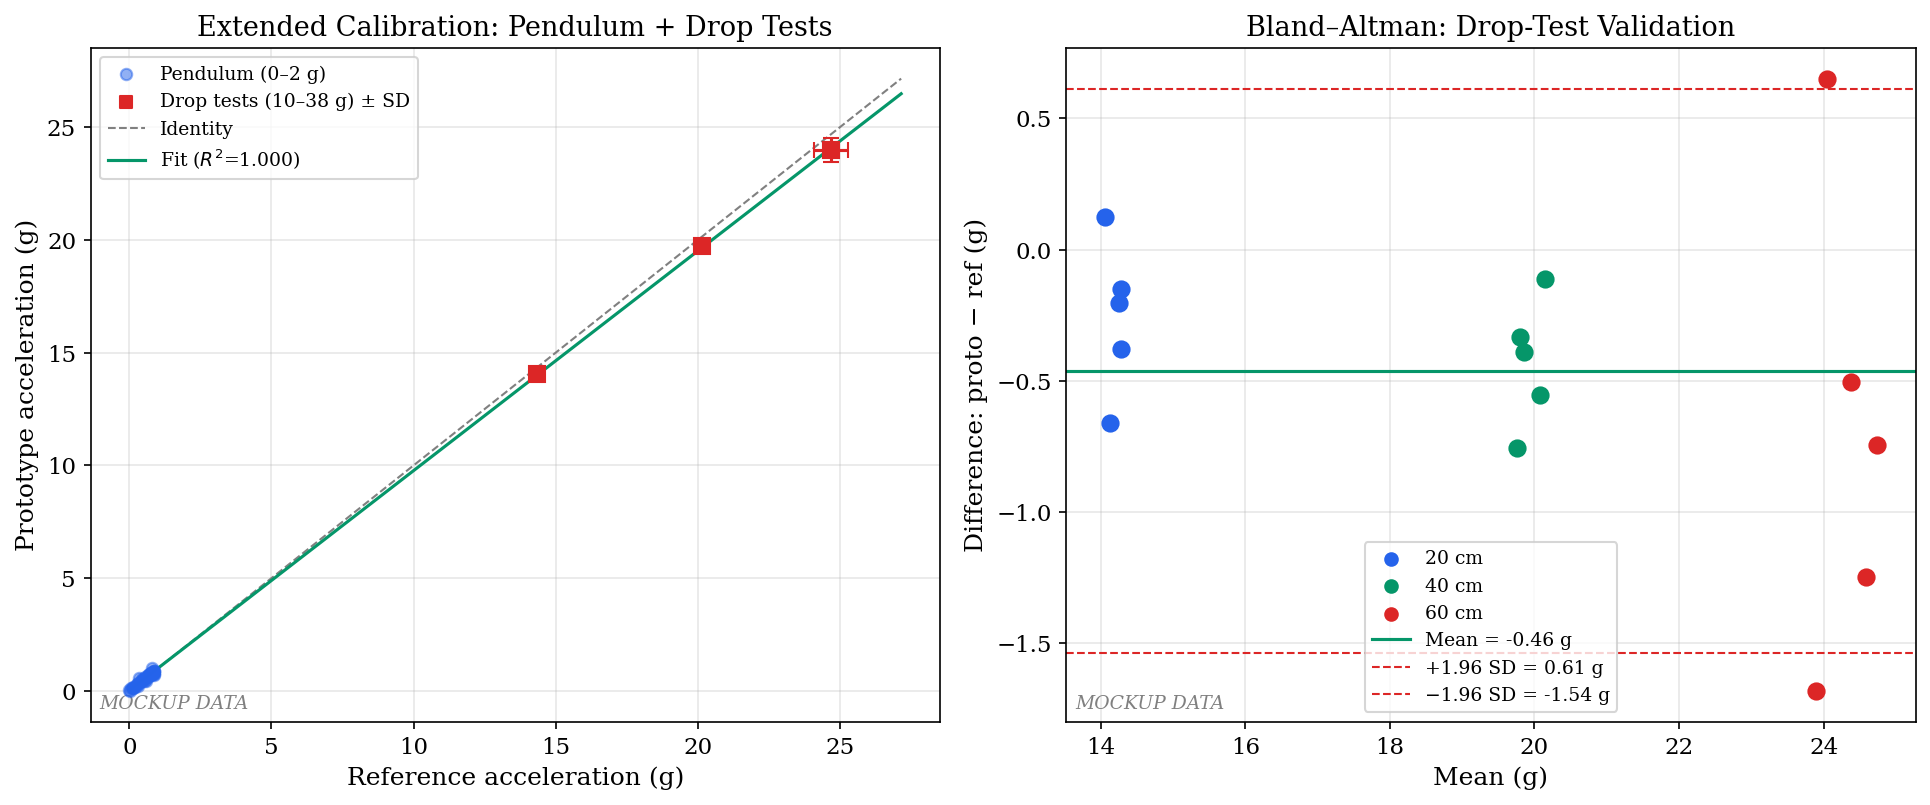

Saved: drop_calibration


In [14]:
# Combined calibration curve: pendulum + drop tests
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: full extended range
ax = axes[0]
# Pendulum points (proto vs ref using theoretical as reference proxy)
pend_ref = np.abs(accel_ref)  # use ref magnitudes
pend_proto = np.abs(accel_proto)

ax.scatter(pend_ref, pend_proto, s=30, color='#2563EB', alpha=0.5, label='Pendulum (0–2 g)', zorder=5)

# Drop test points
for h, proto, ref in zip(drop_heights_cm, proto_readings, ref_readings):
    ax.errorbar(ref.mean(), proto.mean(),
                xerr=ref.std(ddof=1), yerr=proto.std(ddof=1),
                fmt='s', color='#DC2626', markersize=8, capsize=4, zorder=6)
ax.scatter([], [], marker='s', color='#DC2626', label='Drop tests (10–38 g) ± SD')

# Identity + regression over full range
all_ref = np.concatenate([pend_ref, [r.mean() for r in ref_readings]])
all_proto = np.concatenate([pend_proto, [p.mean() for p in proto_readings]])
sl, ic, rv, _, _ = stats.linregress(all_ref, all_proto)
xr = np.linspace(0, all_ref.max() * 1.1, 100)
ax.plot(xr, xr, '--', color='gray', linewidth=1, label='Identity')
ax.plot(xr, sl*xr + ic, '-', color='#059669', linewidth=1.5,
        label=f'Fit ($R^2$={rv**2:.3f})')
ax.set_xlabel('Reference acceleration (g)'); ax.set_ylabel('Prototype acceleration (g)')
ax.set_title('Extended Calibration: Pendulum + Drop Tests')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Right: drop-test Bland-Altman
ax2 = axes[1]
all_ref_drop = np.concatenate(ref_readings)
all_proto_drop = np.concatenate(proto_readings)
avg_d = (all_ref_drop + all_proto_drop) / 2
diff_d = all_proto_drop - all_ref_drop
md_d = np.mean(diff_d); sd_d = np.std(diff_d, ddof=1)
ht_colors = np.repeat(['#2563EB', '#059669', '#DC2626'], 5)
for xi, yi, ci in zip(avg_d, diff_d, ht_colors):
    ax2.scatter(xi, yi, s=60, color=ci, zorder=5)
for ci, lbl in zip(['#2563EB','#059669','#DC2626'], ['20 cm','40 cm','60 cm']):
    ax2.scatter([], [], color=ci, label=lbl)
ax2.axhline(md_d, color='#059669', linewidth=1.5, label=f'Mean = {md_d:.2f} g')
ax2.axhline(md_d + 1.96*sd_d, color='#DC2626', linewidth=1, linestyle='--',
            label=f'+1.96 SD = {md_d+1.96*sd_d:.2f} g')
ax2.axhline(md_d - 1.96*sd_d, color='#DC2626', linewidth=1, linestyle='--',
            label=f'−1.96 SD = {md_d-1.96*sd_d:.2f} g')
ax2.set_xlabel('Mean (g)'); ax2.set_ylabel('Difference: proto − ref (g)')
ax2.set_title('Bland–Altman: Drop-Test Validation')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

if MOCKUP:
    for a in axes:
        a.text(0.01, 0.02, 'MOCKUP DATA', transform=a.transAxes,
               color='gray', fontsize=9, fontstyle='italic')
fig.tight_layout()
fig.savefig(FIG_DIR / 'drop_calibration.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'drop_calibration.png', bbox_inches='tight')
plt.show(); print('Saved: drop_calibration')

## 7. Impact-region identification: confusion matrix + weighted-centroid

**To replace with real data:** Set `MOCKUP = False` and provide:
- `region_true`: list of true region labels (one per trial), e.g. `['F','F','F','F','F','F','F', 'P',...]`
- `channel_readings`: 2-D array, shape (n_trials, 4), raw load-cell readings for channels [F, P, LL, RL]

In [15]:
MOCKUP = True  # <-- set to False and provide real arrays

REGIONS = ['F', 'P', 'LL', 'RL']
REGION_IDX = {r: i for i, r in enumerate(REGIONS)}
SENSOR_POS = np.array([[0, 1],   # F  = top-center
                        [0, -1],  # P  = bottom-center
                        [-1, 0],  # LL = left
                        [1, 0]])  # RL = right

if MOCKUP:
    rng = np.random.default_rng(42)
    channel_readings = []
    region_true = []
    for true_idx, region in enumerate(REGIONS):
        for _ in range(7):
            # Main channel: high signal
            readings = rng.uniform(0.05, 0.15, 4)
            readings[true_idx] = rng.uniform(0.6, 1.0)
            # For boundary cases: 2 trials per F and P get an adjacent spike
            # F -> LL confusion (2 trials), P -> RL confusion (2 trials)
            channel_readings.append(readings)
            region_true.append(region)

    # Inject the 4 known misclassifications
    # Trial 0,1 (F): boost LL above F
    channel_readings[0][REGION_IDX['LL']] = channel_readings[0][REGION_IDX['F']] + 0.05
    channel_readings[1][REGION_IDX['LL']] = channel_readings[1][REGION_IDX['F']] + 0.03
    # Trial 7,8 (P): boost RL above P
    channel_readings[7][REGION_IDX['RL']] = channel_readings[7][REGION_IDX['P']] + 0.04
    channel_readings[8][REGION_IDX['RL']] = channel_readings[8][REGION_IDX['P']] + 0.06

    channel_readings = np.array(channel_readings)

else:
    # === REPLACE WITH YOUR DATA ===
    # region_true      = ['F','F', ...]  # length n_trials
    # channel_readings = np.array([[ch_F, ch_P, ch_LL, ch_RL], ...])  # shape (n_trials, 4)
    raise ValueError('Set MOCKUP=False and provide region_true / channel_readings.')

region_true = np.array(region_true)
n_trials = len(region_true)

# Max-channel prediction
pred_max = np.array([REGIONS[np.argmax(r)] for r in channel_readings])

# Weighted-centroid prediction
def weighted_centroid_predict(readings):
    w = readings / readings.sum()
    centroid = SENSOR_POS.T @ w
    dists = np.linalg.norm(SENSOR_POS - centroid, axis=1)
    return REGIONS[np.argmin(dists)]

pred_wc = np.array([weighted_centroid_predict(r) for r in channel_readings])

acc_max = np.mean(pred_max == region_true) * 100
acc_wc  = np.mean(pred_wc  == region_true) * 100

print(f'Max-channel accuracy:       {acc_max:.1f}%  ({int(acc_max*n_trials/100)}/{n_trials})')
print(f'Weighted-centroid accuracy: {acc_wc:.1f}%  ({int(acc_wc*n_trials/100)}/{n_trials})')
if MOCKUP: print('\n*** MOCKUP DATA ***')

Max-channel accuracy:       85.7%  (24/28)
Weighted-centroid accuracy: 85.7%  (24/28)

*** MOCKUP DATA ***


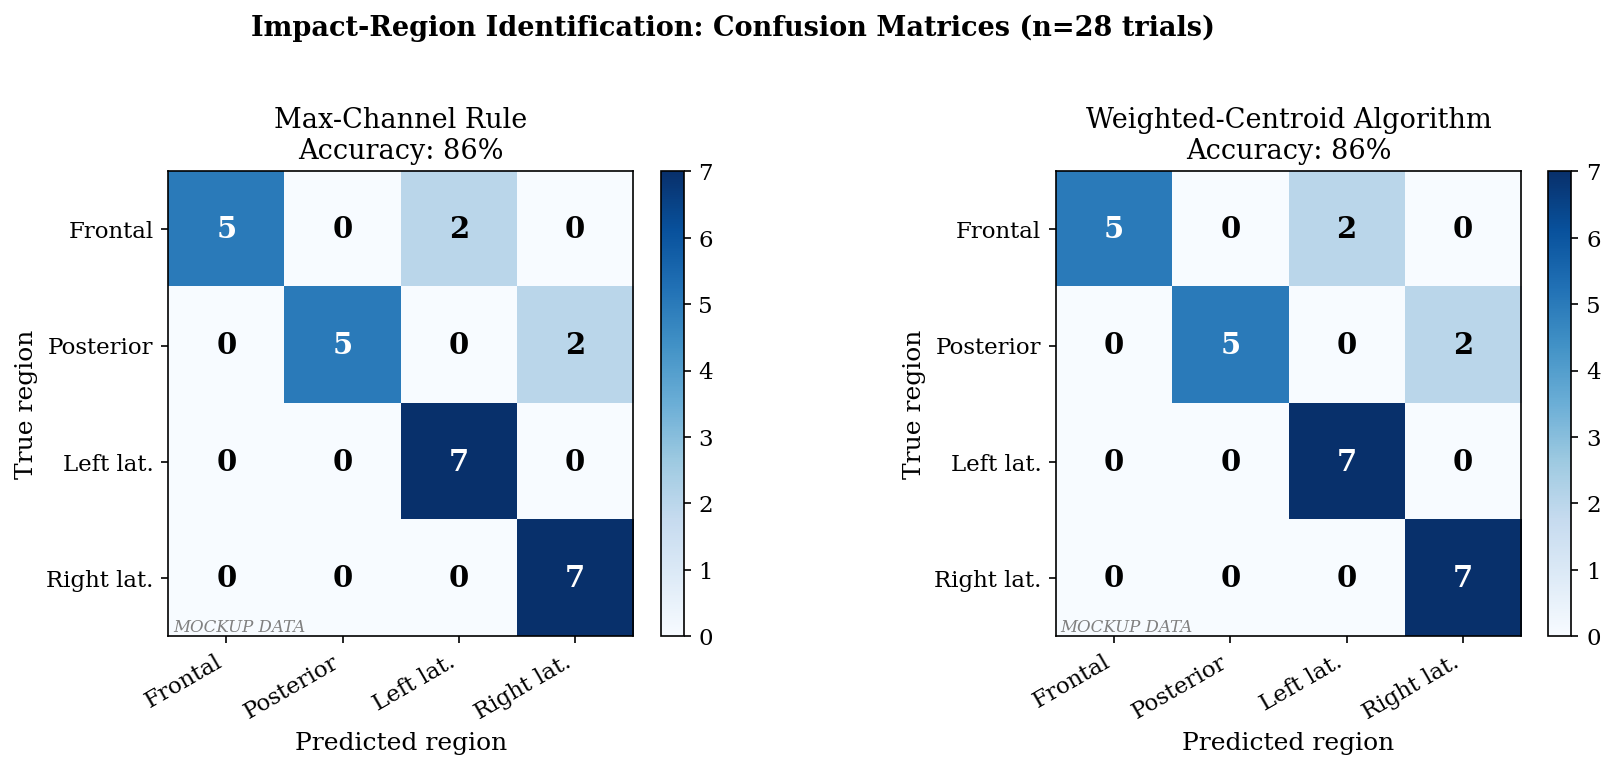

Saved: confusion_matrices


In [16]:
def confusion_matrix_counts(true, pred, labels):
    n = len(labels)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(true, pred):
        cm[labels.index(t), labels.index(p)] += 1
    return cm

cm_max = confusion_matrix_counts(list(region_true), list(pred_max), REGIONS)
cm_wc  = confusion_matrix_counts(list(region_true), list(pred_wc),  REGIONS)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
label_names = ['Frontal', 'Posterior', 'Left lat.', 'Right lat.']

for ax, cm, title, acc in zip(axes,
                               [cm_max, cm_wc],
                               ['Max-Channel Rule', 'Weighted-Centroid Algorithm'],
                               [acc_max, acc_wc]):
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=7)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(label_names, rotation=30, ha='right')
    ax.set_yticklabels(label_names)
    ax.set_xlabel('Predicted region'); ax.set_ylabel('True region')
    ax.set_title(f'{title}\nAccuracy: {acc:.0f}%')
    for i in range(4):
        for j in range(4):
            color = 'white' if cm[i, j] > 4 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if MOCKUP:
        ax.text(0.01, 0.01, 'MOCKUP DATA', transform=ax.transAxes,
                color='gray', fontsize=8, fontstyle='italic')

fig.suptitle(f'Impact-Region Identification: Confusion Matrices (n={n_trials} trials)',
             fontweight='bold', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'confusion_matrices.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show(); print('Saved: confusion_matrices')

## 8. Pendulum theoretical model

Period T = 0.7233 s  |  Frequency f = 1.383 Hz
Tangential accel at release = 8.496 m/s² = 0.8660 g
Total accel at bottom = 19.620 m/s² = 2.000 g


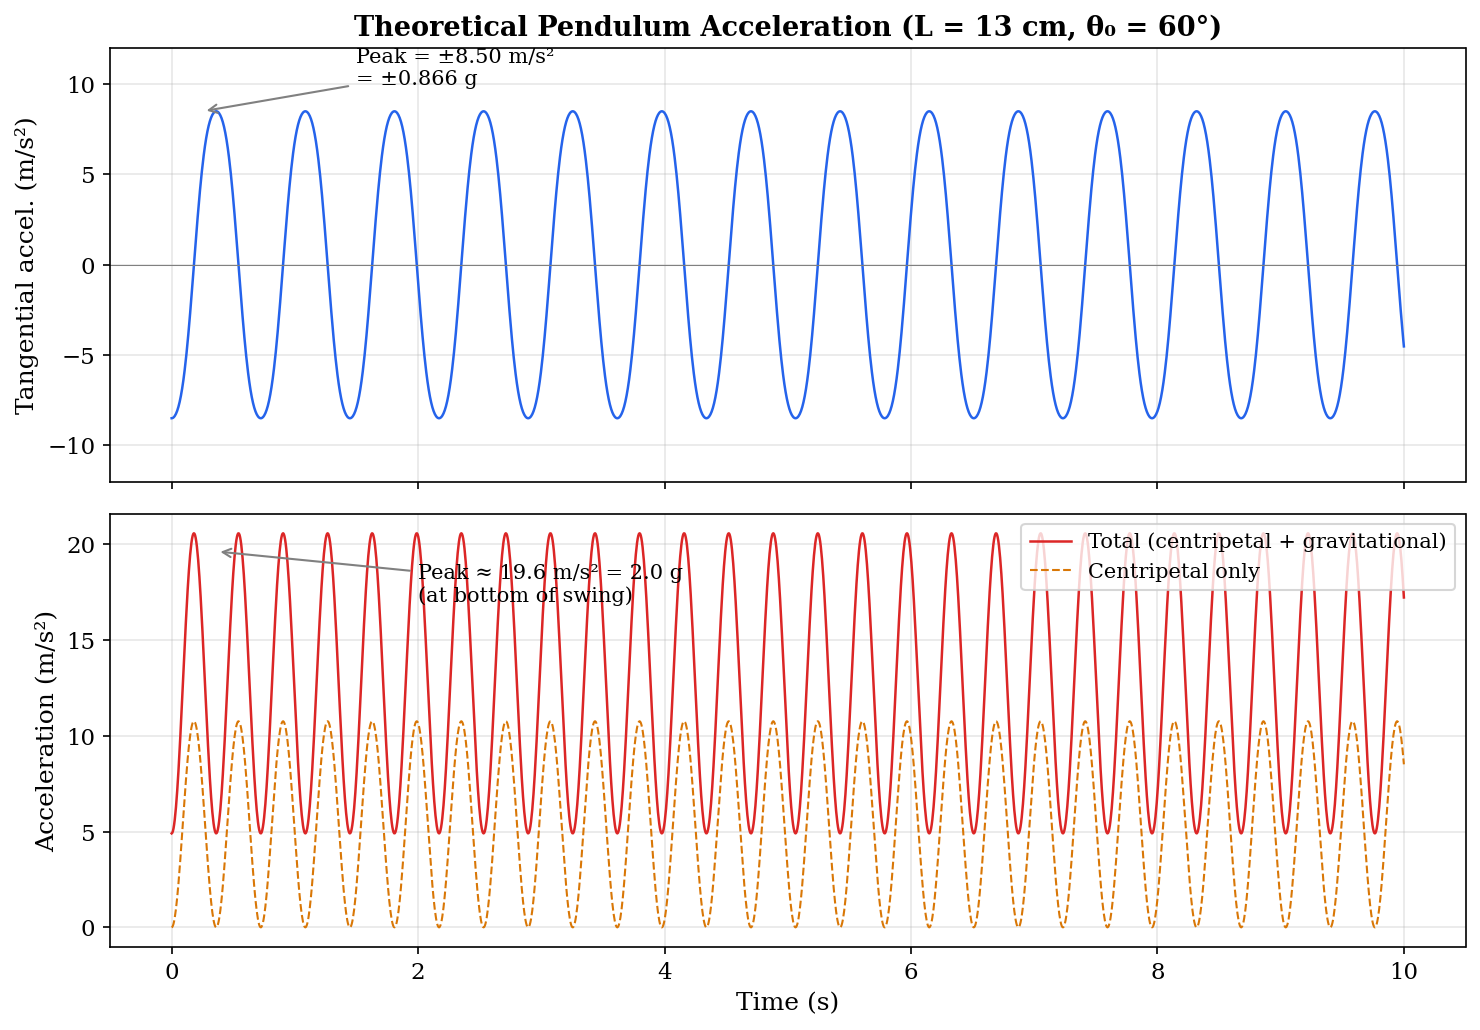

Saved: pendulum_theoretical


In [17]:
L = 0.13; theta0 = 60; g_acc = 9.81
theta_rad = np.radians(theta0)
T_period = 2 * np.pi * np.sqrt(L / g_acc)
f_freq = 1 / T_period
print(f'Period T = {T_period:.4f} s  |  Frequency f = {f_freq:.3f} Hz')
print(f'Tangential accel at release = {g_acc * np.sin(theta_rad):.3f} m/s² = {np.sin(theta_rad):.4f} g')
print(f'Total accel at bottom = {2*g_acc:.3f} m/s² = 2.000 g')

t_sim = np.linspace(0, 10, 2000)
omega = 2 * np.pi * f_freq
theta_t = theta_rad * np.cos(omega * t_sim)
a_tangential = -g_acc * np.sin(theta_t)
dtheta_dt = -theta_rad * omega * np.sin(omega * t_sim)
v = L * dtheta_dt
a_centripetal = v**2 / L

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t_sim, a_tangential, color='#2563EB', linewidth=1.2)
axes[0].set_ylabel('Tangential accel. (m/s²)')
axes[0].set_title('Theoretical Pendulum Acceleration (L = 13 cm, θ₀ = 60°)', fontweight='bold')
axes[0].axhline(0, color='gray', linewidth=0.5); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-12, 12)
axes[0].annotate(f'Peak = ±{g_acc*np.sin(theta_rad):.2f} m/s²\n= ±{np.sin(theta_rad):.3f} g',
                 xy=(0.25, g_acc*np.sin(theta_rad)), fontsize=10,
                 xytext=(1.5, 10), arrowprops=dict(arrowstyle='->', color='gray'))
axes[1].plot(t_sim, a_centripetal + g_acc*np.cos(theta_t), color='#DC2626', linewidth=1.2,
             label='Total (centripetal + gravitational)')
axes[1].plot(t_sim, a_centripetal, color='#D97706', linewidth=1, linestyle='--', label='Centripetal only')
axes[1].set_ylabel('Acceleration (m/s²)'); axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)
axes[1].annotate(f'Peak ≈ {2*g_acc:.1f} m/s² = 2.0 g\n(at bottom of swing)',
                 xy=(T_period/2, 2*g_acc), fontsize=10,
                 xytext=(2, 17), arrowprops=dict(arrowstyle='->', color='gray'))
fig.tight_layout()
fig.savefig(FIG_DIR / 'pendulum_theoretical.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'pendulum_theoretical.png', bbox_inches='tight')
plt.show(); print('Saved: pendulum_theoretical')

## 9. Manuscript summary printout

In [18]:
print('=' * 65)
print('COPY-PASTE SUMMARY FOR MANUSCRIPT')
print('=' * 65)
print()
print('LOAD-CELL CALIBRATION')
print(f'  Regression: y = {slope:.4f}x + {intercept:.2f} g')
print(f'  R² = {r_squared:.7f}')
print(f'  Pearson r = {r_value:.7f}')
print(f'  RMSE = {rmse:.2f} g')
print(f'  Overall MAPE = {mape:.3f}%')
print(f'  Total readings = {len(df)} across {len(summary)} conditions')
print(f'  Bland-Altman: mean diff = {mean_diff:.2f} g, LoA = [{mean_diff-1.96*sd_diff:.2f}, {mean_diff+1.96*sd_diff:.2f}] g')
print()
print('ACCELEROMETER (PENDULUM)')
print(f'  n = {n_accel} paired samples')
print(f'  Agreement (within 10%) = {agreement_pct:.1f}%')
print(f'  MAPE vs BWT61CL = {mape_accel:.2f}%')
print(f'  Bland-Altman: mean diff = {md_a:.4f} g, LoA = [{md_a-1.96*sd_a:.4f}, {md_a+1.96*sd_a:.4f}] g')
print()
print('ACCELEROMETER (DROP TESTS)')
for _, row in drop_summary.iterrows():
    print(f'  {row["Height (cm)"]} cm: theory={row["Theoretical (g)"]:.1f} g, '
          f'proto={row["Proto mean (g)"]:.1f}±{row["Proto SD"]:.2f} g, '
          f'ref={row["Ref mean (g)"]:.1f}±{row["Ref SD"]:.2f} g, '
          f'diff={row["Abs diff (%)"]:.2f}%')
all_ref_all = np.concatenate([pend_ref, [r.mean() for r in ref_readings]])
all_proto_all = np.concatenate([pend_proto, [p.mean() for p in proto_readings]])
_, _, rv_full, _, _ = stats.linregress(all_ref_all, all_proto_all)
print(f'  Combined R² (pendulum + drop) = {rv_full**2:.4f}')
print()
print('IMPACT-REGION IDENTIFICATION')
print(f'  n_trials = {n_trials}  (7 per region × 4 regions)')
print(f'  Max-channel accuracy:       {acc_max:.1f}%  ({int(acc_max*n_trials/100)}/{n_trials})')
print(f'  Weighted-centroid accuracy: {acc_wc:.1f}%  ({int(acc_wc*n_trials/100)}/{n_trials})')
print()
print('PENDULUM THEORY')
print(f'  Theoretical frequency: {f_freq:.3f} Hz (T = {T_period:.4f} s)')
print(f'  Tangential accel at release: {g_acc*np.sin(theta_rad):.3f} m/s² ({np.sin(theta_rad):.4f} g)')
print(f'  Total accel at bottom: {2*g_acc:.3f} m/s² (2.0 g)')
if MOCKUP:
    print()
    print('*** NOTE: accelerometer, drop-test, and region-ID values are MOCKUP.')
    print('    Replace with real data; all figures and stats update automatically.')

COPY-PASTE SUMMARY FOR MANUSCRIPT

LOAD-CELL CALIBRATION
  Regression: y = 0.9992x + 0.81 g
  R² = 0.9999985
  Pearson r = 0.9999992
  RMSE = 2.01 g
  Overall MAPE = 0.329%
  Total readings = 26 across 3 conditions
  Bland-Altman: mean diff = -0.82 g, LoA = [-6.22, 4.59] g

ACCELEROMETER (PENDULUM)
  n = 40 paired samples
  Agreement (within 10%) = 47.5%
  MAPE vs BWT61CL = 70.72%
  Bland-Altman: mean diff = 0.0193 g, LoA = [-0.1186, 0.1571] g

ACCELEROMETER (DROP TESTS)
  20.0 cm: theory=14.4 g, proto=14.1±0.16 g, ref=14.3±0.19 g, diff=1.77%
  40.0 cm: theory=20.4 g, proto=19.7±0.26 g, ref=20.1±0.15 g, diff=2.13%
  60.0 cm: theory=25.0 g, proto=24.0±0.54 g, ref=24.7±0.59 g, diff=2.86%
  Combined R² (pendulum + drop) = 0.9998

IMPACT-REGION IDENTIFICATION
  n_trials = 28  (7 per region × 4 regions)
  Max-channel accuracy:       85.7%  (24/28)
  Weighted-centroid accuracy: 85.7%  (24/28)

PENDULUM THEORY
  Theoretical frequency: 1.383 Hz (T = 0.7233 s)
  Tangential accel at release: 8.4